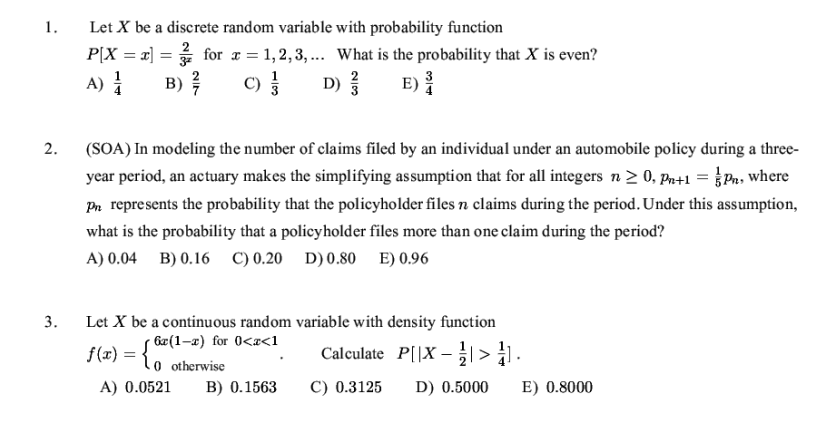

## Ejercicio 1

### Enunciado

Sea $X$ una variable aleatoria discreta con función de probabilidad

$$
P[X = x] = \frac{2}{3^x}, \quad x = 1, 2, 3, \ldots
$$

¿Cuál es la probabilidad de que $X$ sea par?

### Verificación de que es una pmf válida

$$
\sum_{x=1}^{\infty} \frac{2}{3^x} = 2 \sum_{x=1}^{\infty} \left(\frac{1}{3}\right)^x = 2 \cdot \frac{1/3}{1 - 1/3} = 2 \cdot \frac{1}{2} = 1 \;\checkmark
$$

(Serie geométrica con primer término $1/3$ y razón $1/3$.)

### Plantear el suceso

Los valores pares de $X$ son $X \in \{2, 4, 6, \ldots\}$, es decir, $X = 2k$ para $k = 1, 2, 3, \ldots$. Por aditividad sobre valores disjuntos:

$$
P(X \text{ par}) = \sum_{k=1}^{\infty} P(X = 2k) = \sum_{k=1}^{\infty} \frac{2}{3^{2k}} = \sum_{k=1}^{\infty} \frac{2}{9^k}
$$

### Calcular la serie geométrica

Es una serie geométrica con primer término $a = 2/9$ y razón $r = 1/9$. Como $|r| < 1$:

$$
\sum_{k=1}^{\infty} a r^{k-1} \cdot r = \frac{a}{1 - r} = \frac{2/9}{1 - 1/9} = \frac{2/9}{8/9} = \frac{2}{8} = \frac{1}{4}
$$

### Respuesta

$$
\boxed{P(X \text{ par}) = \frac{1}{4}} \quad \text{(opción A)}
$$

In [ ]:
# Verificación del Ejercicio 1
import numpy as np

# Cálculo analítico: suma sobre x par
x_pares = np.arange(2, 200, 2)  # 2, 4, 6, ..., 198
P_par_serie = (2 / 3**x_pares).sum()

# La PMF debe sumar 1
x_todos = np.arange(1, 200)
suma_total = (2 / 3**x_todos).sum()

print(f"Suma de la PMF para x = 1..199: {suma_total:.6f}  (debe ser ≈ 1)")
print(f"P(X par) por suma directa     : {P_par_serie:.6f}")
print(f"Valor exacto (1/4)            : {1/4:.6f}")

# Verificación por simulación
# X tiene CDF F(x) = 1 - (1/3)^x, así que X = ceil(log(1 - U) / log(1/3))
np.random.seed(42)
N = 1_000_000
u = np.random.uniform(size=N)
X = np.ceil(np.log(1 - u) / np.log(1/3)).astype(int)
P_par_sim = np.mean(X % 2 == 0)
print(f"P(X par) por simulación (N = {N:,}): {P_par_sim:.6f}")


## Ejercicio 2

### Enunciado

Un actuario modela el número de reclamos $N$ presentados por un asegurado durante un período de tres años. Asume que, para todo entero $n \geq 0$:

$$
p_{n+1} = \frac{1}{5} p_n
$$

donde $p_n = P(N = n)$. ¿Cuál es la probabilidad de que el asegurado presente **más de un reclamo** durante el período?

### Resolver la recursión

Aplicando la relación repetidamente desde $p_0$:

$$
p_1 = \frac{1}{5}\, p_0, \quad p_2 = \frac{1}{5}\, p_1 = \left(\frac{1}{5}\right)^2 p_0, \quad \ldots \quad p_n = \left(\frac{1}{5}\right)^n p_0
$$

Esto corresponde a una **distribución geométrica** con razón $1/5$ partiendo de $n = 0$.

### Hallar $p_0$ usando que las probabilidades suman 1

$$
\sum_{n=0}^{\infty} p_n = p_0 \sum_{n=0}^{\infty} \left(\frac{1}{5}\right)^n = p_0 \cdot \frac{1}{1 - 1/5} = p_0 \cdot \frac{5}{4} = 1
$$

$$
\Rightarrow p_0 = \frac{4}{5} = 0{,}8
$$

### Calcular $P(N > 1)$

Como $N$ toma valores enteros no negativos:

$$
P(N > 1) = 1 - P(N = 0) - P(N = 1) = 1 - p_0 - p_1
$$

donde:

- $p_0 = \dfrac{4}{5} = 0{,}8$
- $p_1 = \dfrac{1}{5} \cdot p_0 = \dfrac{1}{5} \cdot \dfrac{4}{5} = \dfrac{4}{25} = 0{,}16$

Por lo tanto:

$$
P(N > 1) = 1 - 0{,}8 - 0{,}16 = 0{,}04
$$

### Respuesta

$$
\boxed{P(N > 1) = 0{,}04} \quad \text{(opción A)}
$$

In [ ]:
# Verificación del Ejercicio 2
#
# La recursión p_{n+1} = (1/5) p_n implica p_n = p_0 * (1/5)^n.
# Normalizando para que sumen 1 obtenemos p_0 = 4/5.

p_0 = 4/5
p_1 = (1/5) * p_0

print(f"p_0 (no presenta reclamos)        = {p_0:.4f}")
print(f"p_1 (presenta exactamente 1)      = {p_1:.4f}")
print(f"P(N > 1) = 1 - p_0 - p_1          = {1 - p_0 - p_1:.4f}")

# Comprobación de que las probabilidades suman 1
import numpy as np
n = np.arange(0, 100)
p_n = (4/5) * (1/5)**n
print(f"\nSuma de p_n para n = 0..99: {p_n.sum():.6f} (debe ser 1)")
print(f"P(N > 1) sumando p_n para n >= 2: {p_n[2:].sum():.6f}")


## Ejercicio 3

### Enunciado

Sea $X$ una variable aleatoria continua con función de densidad

$$
f(x) = \begin{cases} 6x(1-x) & \text{para } 0 < x < 1 \\ 0 & \text{en otro caso} \end{cases}
$$

Calcular $P\!\left[\left|X - \tfrac{1}{2}\right| > \tfrac{1}{4}\right]$.

### Verificación de que es una pdf válida

$$
\int_0^1 6x(1-x)\, dx = 6 \int_0^1 (x - x^2)\, dx = 6 \left[\frac{x^2}{2} - \frac{x^3}{3}\right]_0^1 = 6\left(\frac{1}{2} - \frac{1}{3}\right) = 6 \cdot \frac{1}{6} = 1 \;\checkmark
$$

### Reformular el suceso

La condición $\left|X - \tfrac{1}{2}\right| > \tfrac{1}{4}$ equivale a alejarse de $1/2$ en más de $1/4$, es decir:

$$
\left|X - \tfrac{1}{2}\right| > \tfrac{1}{4} \iff X < \tfrac{1}{4} \;\;\text{ó}\;\; X > \tfrac{3}{4}
$$

Como los dos sucesos son disjuntos:

$$
P\!\left[\left|X - \tfrac{1}{2}\right| > \tfrac{1}{4}\right] = P\!\left[X < \tfrac{1}{4}\right] + P\!\left[X > \tfrac{3}{4}\right]
$$

### Aprovechar la simetría

La densidad $f(x) = 6x(1-x)$ es **simétrica respecto a** $x = 1/2$, ya que $f(1-x) = 6(1-x)\, x = f(x)$. Por lo tanto:

$$
P\!\left[X < \tfrac{1}{4}\right] = P\!\left[X > \tfrac{3}{4}\right]
$$

y basta con calcular una de las dos integrales y duplicar.

### Calcular la integral

$$
P\!\left[X < \tfrac{1}{4}\right] = \int_0^{1/4} 6x(1-x)\, dx = 6\left[\frac{x^2}{2} - \frac{x^3}{3}\right]_0^{1/4}
$$

Evaluando en $x = 1/4$:

$$
\frac{(1/4)^2}{2} = \frac{1}{32}, \qquad \frac{(1/4)^3}{3} = \frac{1}{192}
$$

Restando con denominador común $192$:

$$
\frac{1}{32} - \frac{1}{192} = \frac{6}{192} - \frac{1}{192} = \frac{5}{192}
$$

Por lo tanto:

$$
P\!\left[X < \tfrac{1}{4}\right] = 6 \cdot \frac{5}{192} = \frac{30}{192} = \frac{5}{32}
$$

### Sumar las dos contribuciones

$$
P\!\left[\left|X - \tfrac{1}{2}\right| > \tfrac{1}{4}\right] = 2 \cdot \frac{5}{32} = \frac{10}{32} = \frac{5}{16} = 0{,}3125
$$

### Respuesta

$$
\boxed{P\!\left[\left|X - \tfrac{1}{2}\right| > \tfrac{1}{4}\right] = 0{,}3125} \quad \text{(opción C)}
$$

In [ ]:
# Verificación del Ejercicio 3
import numpy as np
from scipy import integrate

# Cálculo analítico exacto de la integral
P_X_menor_un_cuarto, _ = integrate.quad(lambda x: 6 * x * (1 - x), 0, 1/4)
P_evento = 2 * P_X_menor_un_cuarto

print(f"P(X < 1/4)                = {P_X_menor_un_cuarto:.6f}")
print(f"P(X > 3/4)                = {P_X_menor_un_cuarto:.6f}  (por simetría)")
print(f"P(|X - 1/2| > 1/4)        = {P_evento:.6f}")
print(f"Valor esperado (5/16)     = {5/16:.6f}")

# Verificación por simulación (la densidad 6x(1-x) es la Beta(2, 2))
from scipy import stats
np.random.seed(42)
N = 1_000_000
muestras = stats.beta.rvs(2, 2, size=N)
P_sim = np.mean(np.abs(muestras - 0.5) > 1/4)
print(f"\nP(|X - 1/2| > 1/4) por simulación (N = {N:,}): {P_sim:.6f}")
